# CSCI1409 Deep Learning вЂ” Week 4 SIS Mini-project 1
## FashionMNIST: train your first MLP and read its loss curves

**SIS mini-project 1:** 4 course points В· **Defense:** in class, Week 4  
**Goal:** build a small neural network (MLP), train it twice вЂ” once with **SGD** and once with **Adam** вЂ” and plot how the **loss** changes on training and validation data.

You work in groups of 3. Apart from the dataset download, **all code in this notebook is written by your group.** The cells only contain `# TODO` comments with hints. Every student must be able to explain every line and every plot. Write short answers in the answer cells (2вЂ“3 sentences each is enough).

**Before class:** make sure `torch`, `torchvision`, and `matplotlib` are installed ([PyTorch setup guide](https://pytorch.org/get-started/locally/)). The first download of FashionMNIST needs internet. **A CPU is enough** вЂ” no GPU needed.

### AI-use rule for this lab (Level C вЂ” AI-Assisted)

You may use generative AI to get ideas, explain concepts, debug code, or get feedback. However, **your group must write the main solution yourselves** and **understand and check everything you submit**. At the defense you will explain your code and plots without AI help вЂ” "the AI wrote it" is not an answer.

Check AI explanations against the lectures and the PyTorch documentation. Plagiarism, copying another group's code, and invented results are not allowed under any circumstances. If you used an external source (tutorial, blog, docs), name it in your answers.

## 1. Dataset

FashionMNIST has 28Г—28 grayscale images of clothing in 10 classes (T-shirt, trouser, sneaker, вЂ¦). The download code is given. We use only the **official training portion**; the official test set is not used today.

Key words:
- **Training set** вЂ” the images the model learns from (used to compute gradients).
- **Validation set** вЂ” images the model never learns from; we use them only to check how well it works on *new* data.

In [1]:
# PROVIDED: download/load the official training portion.
# ToTensor gives each image the shape [1, 28, 28] with pixel values in [0, 1].
from pathlib import Path
from torchvision import datasets, transforms

# Save downloaded files in the data folder beside this notebook.
_working_dir = Path.cwd()
DATA_ROOT = _working_dir / "data" if _working_dir.name.lower() == "sis1" else _working_dir / "sis1" / "data"

full_training_data = datasets.FashionMNIST(
    root=str(DATA_ROOT),
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)
print("Dataset folder:", DATA_ROOT.resolve())
print("Official training portion:", len(full_training_data), "images")
print("Classes:", full_training_data.classes)

100.0%
100.0%
100.0%
100.0%

Dataset folder: C:\Users\Ануар\Desktop\Папки\Anuar\DeepLearning\sis1\data
Official training portion: 60000 images
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

SEED = torch.Generator().manual_seed(42)

In [13]:
subset_size = 6000
train_size = 5000
val_size = 1000
unused_size = len(full_training_data) - subset_size

train_dataset, val_dataset, _ = torch.utils.data.random_split(
    full_training_data,
    [train_size, val_size, unused_size],
    generator=SEED,
)

print(f"Number of train images: {len(train_dataset)}")
print(f"Number of val images: {len(val_dataset)}")

Number of train images: 5000
Number of val images: 1000


Image shape: torch.Size([1, 28, 28])
Label: 9
Class name: Ankle boot


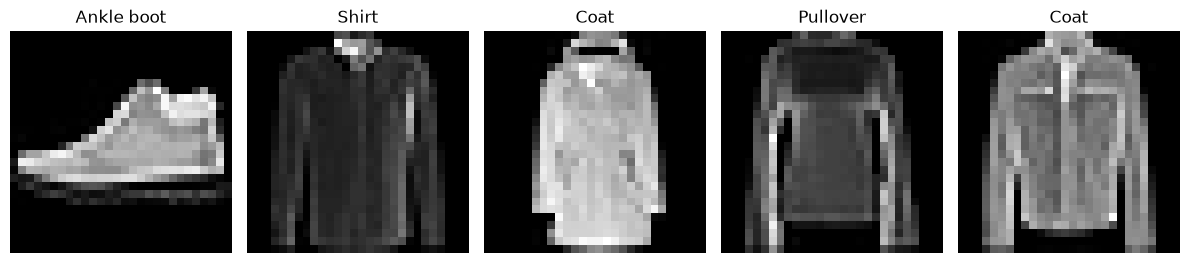

In [14]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class name:", full_training_data.classes[label])

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(full_training_data.classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Your answer вЂ” dataset**

- How many images are in train and in val?
- What does the shape `[1, 28, 28]` mean?
- Why must validation images never be used to update the model's weights?

_Write your answers here._

In [ ]:
5000 train and 1000 validation the other 54k is not used
1 for channels 28 by 28 is weight and hieght
Validation images are only used to check the model.
We do not use them to update the weights because then the validation result will not be a fair test on new data.

## 2. Build your model

Design a small **MLP** (multi-layer perceptron). Requirements:

- input: a batch of images of shape `[1, 28, 28]` в†’ flatten to 784 numbers
- at least **one hidden layer** with a nonlinearity (e.g. ReLU)
- output: **10 numbers per image** (one score вЂ” a *logit* вЂ” per class)

A simple design is enough, e.g. `784 в†’ 128 в†’ 10`.

In [ ]:
class MLP(nn.Module):
    def init(self):
        super().init()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
model = MLP()
print(model)

In [ ]:
# TODO: pass a small batch of images through the model and check the output shape is (batch_size, 10)

**Your answer вЂ” model**

- Write your architecture (layer sizes and activation).
- Why do we need a nonlinearity between the layers?

_Write your answers here._

## 3. Training setup

Use these **suggested settings** (you may change them, but write down what you used):

| Setting | Suggested value |
|---|---|
| Batch size | 64 |
| Epochs | 10 |
| SGD learning rate | 0.1 |
| Adam learning rate | 0.001 |

Keep the model, seed, batch size, and number of epochs **the same** for SGD and Adam вЂ” only the optimizer changes. That way the comparison is fair.

In [ ]:
# TODO: create a DataLoader for train (shuffle=True) and one for val (shuffle=False)
# TODO: choose a loss function for 10-class classification

**Your prediction (write it BEFORE training)**

- Which optimizer do you think will make the training loss go down faster: SGD or Adam? Why?

_Write your prediction here._

## 4. Training and evaluation code

Write two functions yourselves:

1. **`train_one_epoch`** вЂ” goes through all training batches once. For each batch:  
   (a) clear old gradients в†’ (b) forward pass в†’ (c) compute the loss в†’ (d) backpropagate в†’ (e) update the weights.  
   Use `model.train()`.
2. **`evaluate`** вЂ” returns the average loss and accuracy on a loader. Use `model.eval()` and `torch.no_grad()`, so **no gradients and no weight updates** happen here.

At the defense you must point to the lines (a)вЂ“(e) in your code.

In [ ]:
# TODO: write train_one_epoch(model, loader, loss_fn, optimizer)
#       zero_grad -> forward -> loss -> backward -> step

In [ ]:
# TODO: write evaluate(model, loader, loss_fn) that returns (average loss, accuracy)

In [ ]:
# TODO: write run_experiment(optimizer_name, lr) that:
#       - resets the seed and builds a NEW model (so both runs start from the same weights)
#       - creates the optimizer: torch.optim.SGD or torch.optim.Adam
#       - for each epoch: train once, then evaluate on train and on val
#       - stores train loss and val loss for every epoch in two lists and returns them
#       - prints epoch number, train loss, val loss, val accuracy

## 5. Run SGD and Adam

In [ ]:
# TODO: run the experiment with SGD

In [ ]:
# TODO: run the experiment with Adam

## 6. Plot the loss curves

This is the main result of the lab. A **loss curve** shows the loss (y-axis) after each epoch (x-axis).

In [ ]:
# TODO: plot train loss and val loss vs epoch for SGD and for Adam
#       (e.g. two panels side by side, same y-axis range; add a title, axis labels, and a legend)
# TODO: print the final train loss, final val loss, and final val accuracy for both runs

**Your answer вЂ” curves**

- Which optimizer reduced the training loss faster? Give one epoch and the numbers.
- Was your prediction correct?
- Look at the gap between train loss and val loss. Is the model overfitting (val loss goes up while train loss keeps going down), underfitting (both stay high), or fitting well?
- The two optimizers used different learning rates. Why does that make the comparison less clear-cut?

_Write your answers here. A surprising result is fine if you explain it with your plots._

## 7. Group contribution statement (required)

For each member, write what they did (e.g. data split, model, training loop, plots, answers) and how the group used AI (what for, and how you checked it). Every member must still be able to explain the whole notebook.

| Student (full name) | Main contribution | How AI was used and checked |
|---|---|---|
|  |  |  |
|  |  |  |
|  |  |  |

## 8. Defense checklist and grading

**Submit this completed notebook** (or an HTML/PDF export with all cells and plots visible) before your defense. Each group has a short (~5 min) defense. Any member may be asked to:

- explain any line of your code вЂ” the split, the model, and the training steps (a)вЂ“(e)
- explain why `model.eval()` and `torch.no_grad()` are used in `evaluate`
- read your loss plots: which optimizer was faster, and is there overfitting?
- say what AI helped with and how you checked it

The Week 4 SIS mini-project is worth **4 points**:

| Criterion | Points |
|---|---|
| Working code written by the group: data split, MLP, training loop, and evaluation; both SGD and Adam runs complete | 1 |
| Clear loss plots: train and val loss vs epoch for both optimizers, with title, axis labels, and legend | 1 |
| Answers: correct, short explanations of the dataset, model, and curves, based on your own numbers | 1 |
| Individual oral explanation of the group's code and plots at the defense | 1 |
| **Total** | **4** |

**Optional (no extra points):** add dropout (`nn.Dropout(0.3)`) after the hidden layer, train with Adam again, and compare the new loss curves with your old Adam curves. Did the train/val gap change?